### **Quest)** 고양이 사진을 사막 배경에 합성하기

In [1]:
# 1. 라이브러리 임포트
!pip install opencv-python pixellib

import os
import cv2
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

print(cv2.__version__)

4.13.0


원본 고양이 이미지 크기: (516, 387, 3)
배경(사막) 이미지 크기: (1024, 1553, 3)


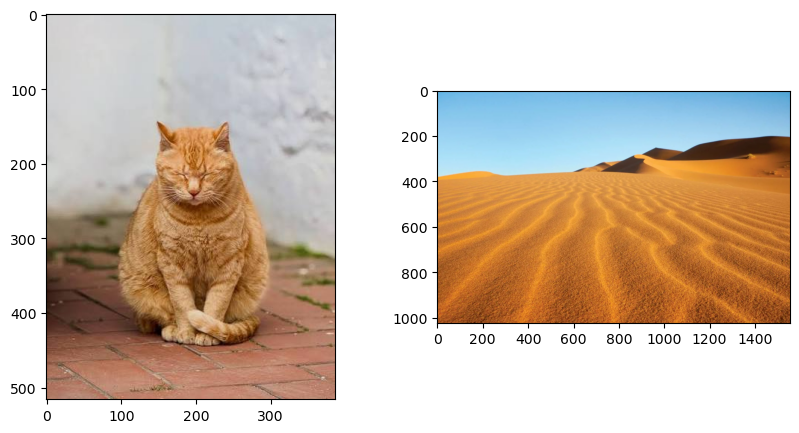

In [2]:
# 2. 이미지 로드 및 초기 확인
home_dir = os.getenv('HOME')
cat_img_path = os.path.join(home_dir, 'work/AIFFEL_Quest_ENG/03_Computer_Vision/CV02/image/cat.png') 
sand_img_path = os.path.join(home_dir, 'work/AIFFEL_Quest_ENG/03_Computer_Vision/CV02/image/sand.png') 

cat_img = cv2.imread(cat_img_path)
sand_img = cv2.imread(sand_img_path)

# BGR > RGB 형식 변환
cat_img = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)
sand_img = cv2.cvtColor(sand_img, cv2.COLOR_BGR2RGB)

print(f"원본 고양이 이미지 크기: {cat_img.shape}")
print(f"배경(사막) 이미지 크기: {sand_img.shape}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cat_img)

plt.subplot(1, 2, 2)
plt.imshow(sand_img)

plt.show()

In [3]:
# 3. 세그멘테이션 모델 로드 및 추론
model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기
    T.ToTensor(),
])

input_tensor = transform(cat_img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

print(f"추론 마스크 크기 (Before Resize): {output_predictions.shape}")

/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


추론 마스크 크기 (Before Resize): (520, 520)


In [4]:
# 마스크를 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (cat_img.shape[1], cat_img.shape[0]), interpolation=cv2.INTER_NEAREST)

print(f"추론 마스크 크기 (After Resize): {output_predictions_resized.shape}")

추론 마스크 크기 (After Resize): (516, 387)


In [5]:
unique_classes = np.unique(output_predictions_resized)
print(f"예측된 클래스 ID: {unique_classes}")

예측된 클래스 ID: [0 8]


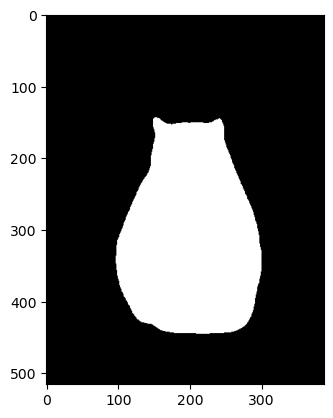

In [6]:
target_class_id = unique_classes[-1]

seg_map = (output_predictions_resized == target_class_id)
img_mask = seg_map.astype(np.uint8) * 255

plt.imshow(img_mask, cmap='gray')
plt.show()

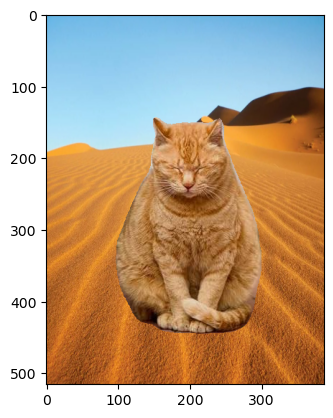

In [7]:
# 배경을 고양이 이미지 크기에 맞춤
sand_img_resized = cv2.resize(sand_img, (cat_img.shape[1], cat_img.shape[0]))

# 고양이 부분만 남기고 배경 적용
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)  # 3채널 변환
result_img = np.where(img_mask_color == 255, cat_img, sand_img_resized)  # 마스크 기반 합성

plt.imshow(result_img)
plt.show()

### **Quest)** 합성된 사진에 아웃포커싱 효과 주기

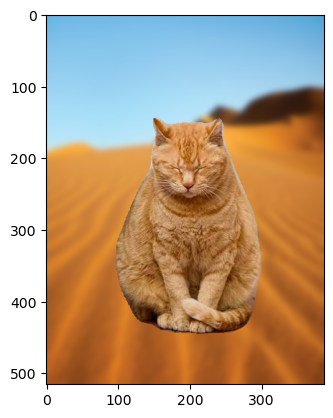

In [8]:
# 배경 이미지 블러 처리 (아웃포커싱)
blurred_sand_img = cv2.GaussianBlur(sand_img_resized, (25, 25), 0)

# 마스크 기반 합성 (블러 처리된 배경 사용)
result_img_outfocus = np.where(img_mask_color == 255, cat_img, blurred_sand_img)

# 결과 출력
plt.imshow(result_img_outfocus)
plt.show()

### **Step 2)** 사진에서 문제점 찾기  
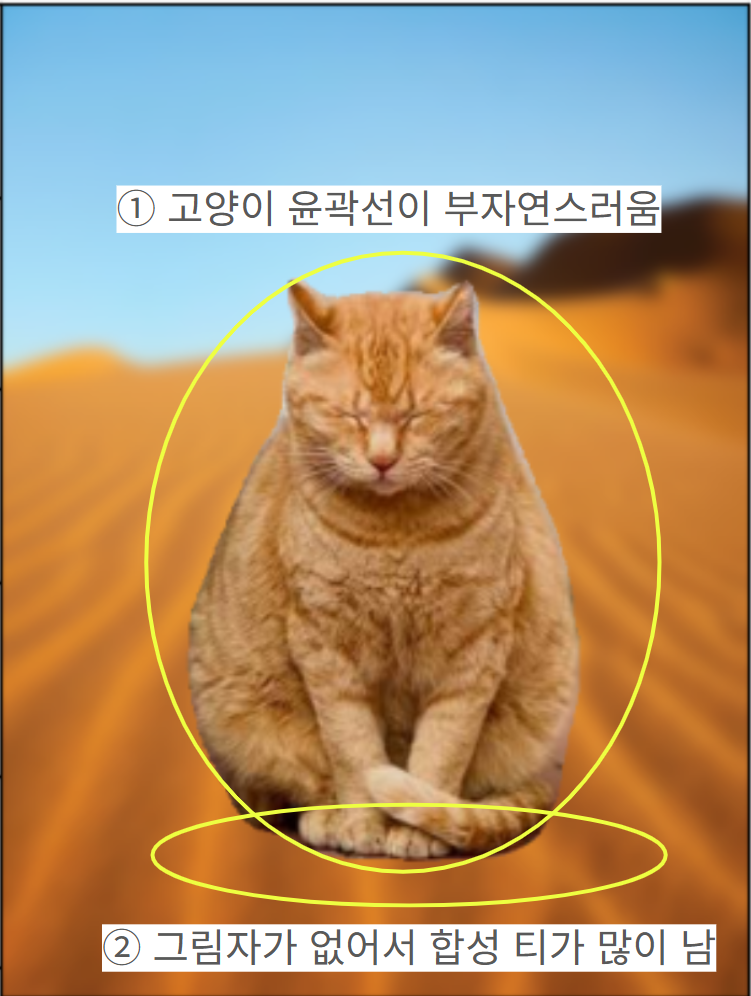  

### 1. 고양이 외곽선이 부자연스러움  
#### - 잘린 부분은 직선이지만 **고양이 털**을 표현하는 데 부적절함 
#### **(해결방안)** 마스크 가장자리에 부드러운 블러(Gaussian Blur)를 적용하여 알파 블랜딩(Alpha Blending) 처리를 통해 부드러운 털의 경계를 구현함  

### 2. 고양이의 그림자가 없어서 합성한 티가 많이 남  
#### **(해결방안)** 고양이 마스크를 추출하여 살짝 아래로 내려서 그림자의 방향성을 부여하고, 블러 처리를 하여 그림자처럼 보이도록 함.  
#### 그림자에는 투명도를 주어서 자연스럽게 표시되도록 함.  


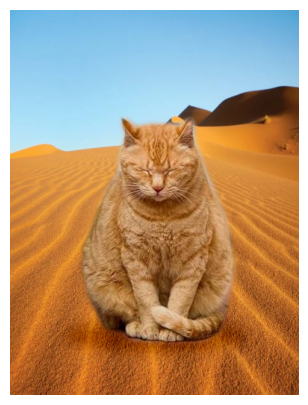

In [20]:
# 1. 마스크 경계 부드럽게 만들기
mask_blurred = cv2.GaussianBlur(img_mask, (15, 15), 0)
alpha = mask_blurred.astype(float) / 255.0  

# 2. 그림자 생성 (BGR 컬러 환경 유지)
# shadow_layer를 uint8로 생성
shadow_layer = np.zeros_like(sand_img_resized, dtype=np.uint8)
h, w = cat_img.shape[:2]
# 발 밑에 어두운 회색 타원 그리기 (색상: (50, 50, 50))
cv2.ellipse(shadow_layer, (w // 2, h - 80), (120, 20), 0, 0, 360, (50, 50, 50), -1)
shadow_blurred = cv2.GaussianBlur(shadow_layer, (51, 51), 0)

# 3. 배경에서 그림자 빼기 (uint8 환경에서 수행)
final_background = cv2.subtract(sand_img_resized, shadow_blurred)

# 4. 알파 블렌딩 합성
cat_float = cat_img.astype(float)
bg_float = final_background.astype(float)

# 채널 확장 후 합성
alpha_3 = alpha[:, :, np.newaxis]
result = (cat_float * alpha_3 + bg_float * (1 - alpha_3))

# 최종 결과 출력
plt.figure(figsize=(10, 5))
plt.imshow(result.astype(np.uint8))
plt.axis('off')
plt.show()

### 회고  

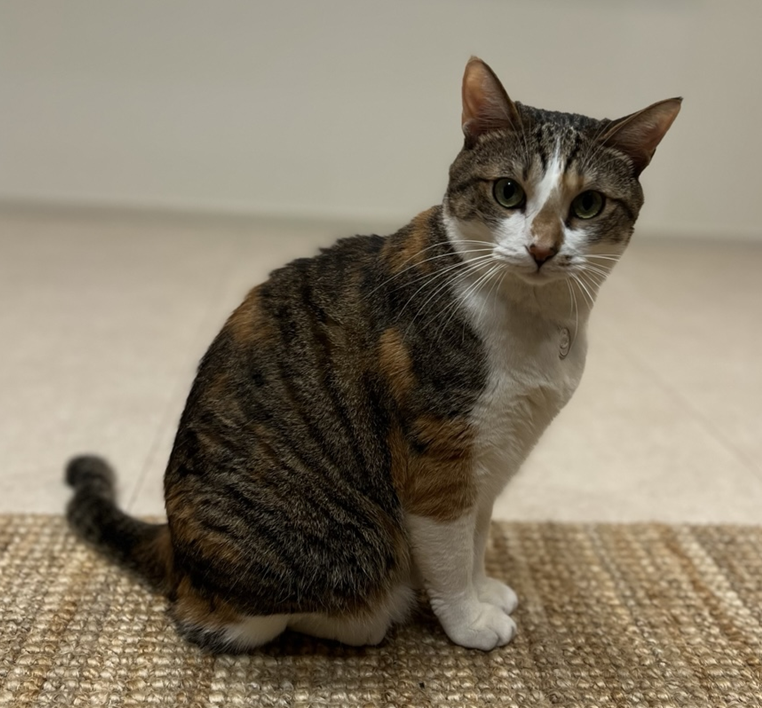  

#### - 최근에 아이폰 인물사진모드로 찍은 고양이 사진을 꺼내 살펴보니, 단순히 피사체의 윤곽을 잘라서 배경에 합성하는 방식이 아닌 고도화된 기술이 들어가 있다는 생각이 들었습니다.  

#### - 고양이보다 살짝 뒤에 있는 꼬리에 더 강한 블러처리 하였고, 고양이의 머리와 몸통에도 거리에 따라 세밀하게 블러 처리를 하여 더욱 사실적으로 아웃포커싱이 된 것처럼 보였습니다.  

#### - 초창기 인물사진의 경우 확대 시 마스크 영역을 이상하게 잡거나, 부자연스러운 부분이 많았던 기억이 있는데, 그만큼 다양한 솔루션이 적용되었다는 걸 느꼈습니다.  